# Selenium이란?
* 웹브라우저를 자동으로 제어하는 라이브러리
* 원래 다양한 웹브라우저를 자동으로 테스트하는 도구
* 코드를 통해 웹브라우저 조작 가능
* 동적 웹사이트에서 정보를 가져오는데 활용

In [13]:
# !pip install selenium
# !pip install webdriver-manager

In [1]:
import selenium
print(selenium.__version__)

4.31.0


In [3]:
!pip install webdriver-manager

In [4]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")


driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )
driver.get("https://search.shopping.naver.com/book/search?bookTabType=ALL&pageIndex=1&pageSize=40&prevQuery=%EB%84%A4%EC%9D%B4%EB%B2%84%20%EC%B1%85&query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&sort=REL")

# selenium에서 원하는 요소찾기
* driver.find_element(By.CSS_SELECTOR, css셀렉터): 1개의 요소 찾기
* driver.find_elements(By.CSS_SELECTOR, css셀렉터): 여러개의 요소 찾기, list반환
* driver.find_element(By.ID, "id"): html에서 id 속성을 찾아줌
* driver.find_element(By.LINK_TEXT, "link에 포함된 문자"): link에 포함된 문자 찾기
* driver.find_element(By.PARTIAL_LINK_TEXT, "link에 포함된 일부 문자"): link에 포함된 문자 찾기


In [5]:
driver.find_element(By.CSS_SELECTOR, "div.bookListItem_title__1mWGq").text

'혼자 만들면서 공부하는 파이썬 (37개 라이브러리와 API로 보고서, 차트, 게임, 맵, AI 챗봇 만들기|저자 직강 유튜브 강의, 오픈 채팅 제공)'

In [73]:
# driver.find_element(By.ID, "book_list").get_attribute("innerHTML")

In [6]:
driver.find_element(By.PARTIAL_LINK_TEXT, "점프").get_attribute("innerHTML")

'<div class="bookListItem_thumbnail_area__W3MCC"><div class="bookListItem_thumbnail__ABXyE"><img src="https://shopping-phinf.pstatic.net/main_4035408/40354085633.20230927071024.jpg?type=w300" alt="Do it! 점프 투 파이썬"></div></div><div class="bookListItem_text_area__6gSV2"><div class="bookListItem_feature__Tck1v">컴퓨터/IT 9위</div><div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>Do it! 점프 투 파이썬</span><span> (중학생도 첫날부터 실습하는 초고속 입문서)</span></span></div><div class="bookListItem_detail__VW1kD"><div class="bookListItem_define_item__jqcW8"><span class="bookListItem_define_title__W5Fg6">저자</span><span class="bookListItem_define_data__fu2A5">박응용</span></div><div class="bookListItem_define_item__jqcW8 bookListItem_publish__6XykH"><div class="bookListItem_detail_publish__SGgZN"><span class="bookListItem_define_title__W5Fg6">출판</span><span class="bookListItem_define_data__fu2A5">이지스퍼블리싱</span></div><div class="bookListItem_detail_date__6_wYJ">2023.06.15.</div></div></di

In [7]:
driver.find_element(By.CSS_SELECTOR, ".bookListItem_grade__e60mi").text

'평점5.0 (4)'

# 찾은 요소에서 요소의 속성값 출력하기
* find_element(By.CSS_SELECTOR, "css셀렉터").get_attribute("속성명")

In [8]:
seller_link = "#book_list > ul > li:nth-child(1) > div > div > div:nth-child(1) > a"

In [9]:
driver.find_element(By.CSS_SELECTOR, seller_link).get_attribute("data-shp-page-key")

'100388780'

In [10]:
import time
y = 0
y_step = 1000
for scroll_times in range(1, 8):
    y = y + y_step
    driver.execute_script(f"window.scrollTo({0}, {y})")
    time.sleep(2)

In [11]:
driver.find_element(By.CSS_SELECTOR, "div.bookListItem_title__1mWGq").text

'혼자 만들면서 공부하는 파이썬 (37개 라이브러리와 API로 보고서, 차트, 게임, 맵, AI 챗봇 만들기|저자 직강 유튜브 강의, 오픈 채팅 제공)'

In [12]:
driver.find_element(By.CSS_SELECTOR, ".bookListItem_item_inner__edK7P > a").get_attribute("href")

'https://cr3.shopping.naver.com/book/adcr?x=GGL7Dn3x4XB6zf3nfFkqgv%2F%2F%2Fw%3D%3Ds8rMaHVwYYg1uehQUrtN28uX0iWydDza7P5KtN0nNQ1roLdJsmLe0ih5KVXMQNR0trJuUVrVAXo8IWUNU%2BPG6pgWS9QQ1pcCh0Cz8JUj5E0%2BjTD98vqxGa%2Bu%2BWRiHHJK3OtBHJ5Az34dROngELGiQV1Vd6Z%2BmZ5fvTALbBBPmfKIKVnJqocqfFwLra6hFr54BChrcdh1ag7%2ByRqH4qgSPNfj6xDMeJaPTHtDIoNWns%2BM%2BoN22s6dKwm7Qn7boTIbfqCLVLVQWWN%2FLTnvTKQyWvKuKWQN4b7WstTXVRp4V%2Fd0JKrZo3FQ8qJiOJvuw2RKHAZb6IA6bgJRD823n6I7zSWtr6kjpQm75PC01ZTCp2UiFGuCM%2FCk3GgnPWTWNZYBs6ghcEmaFB5Xd%2FGJcf3ZxM9NOa4m%2FQNSmmKDdN31asZHfhZnjeQ91WOgG3%2F%2B14gxfU2OusK2AneTUA0rL1XJzuieAGZ88lPBOr4VzV946h8hSq1JQwFWfln1fp8dSeH72Vjd7jI5mVEOJszmlbQ8To33b5Z1u%2Bn3fn%2FJyFD7BrJJhJXGGt6PeWS7xsJOEDFvB63amo3CAIgaDXQIo6fYMWgryvEhEZOL0vuCQNWWktk8tv14vi5WSJ1CQMeM9rnwvzUhNzs2VE%2B%2Bisqs3JAEppg%3D%3D&nvMid=52859338841&catId=50010920'

In [13]:
driver.find_element(By.PARTIAL_LINK_TEXT, "파이썬").get_attribute('innerHTML')

'<div class="bookListItem_thumbnail_area__W3MCC"><div class="bookListItem_thumbnail__ABXyE"><img src="https://shopping-phinf.pstatic.net/main_5285933/52859338841.20250209071357.jpg?type=w300" alt="혼자 만들면서 공부하는 파이썬"></div></div><div class="bookListItem_text_area__6gSV2"><div class="bookListItem_feature__Tck1v">컴퓨터/IT 103위</div><div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>혼자 만들면서 공부하는 파이썬</span><span> (37개 라이브러리와 API로 보고서, 차트, 게임, 맵, AI 챗봇 만들기|저자 직강 유튜브 강의, 오픈 채팅 제공)</span></span></div><div class="bookListItem_detail__VW1kD"><div class="bookListItem_define_item__jqcW8"><span class="bookListItem_define_title__W5Fg6">저자</span><span class="bookListItem_define_data__fu2A5">문현일</span></div><div class="bookListItem_define_item__jqcW8 bookListItem_publish__6XykH"><div class="bookListItem_detail_publish__SGgZN"><span class="bookListItem_define_title__W5Fg6">출판</span><span class="bookListItem_define_data__fu2A5">한빛미디어</span></div><div class="bookListItem_det

# 검색창을 찾아 검색어 입력하고 서치버튼 클릭하기
* 키보드 입력하기
  * driver.send_keys("핀테크").send_keys("ENTER")
* 마우스 클릭하기
  * driver.click()

In [14]:
driver.find_element(By.CSS_SELECTOR, "._searchInput_search_text_83jy9._nlog_click").get_attribute('outerHTML')

'<input type="text" class="_searchInput_search_text_83jy9 _nlog_click" title="검색어 입력" placeholder="상품명 또는 브랜드 입력" maxlength="50" data-shp-page-key="100388780" data-shp-nsc="shopping.book" data-shp-inventory="GNB" data-shp-area="GNB.input" data-shp-area-type="action" data-shp-area-id="input" value="파이썬">'

In [15]:
serch_box = driver.find_element(By.CSS_SELECTOR, "._searchInput_search_text_83jy9._nlog_click")
serch_box.clear()
serch_box.send_keys("파이썬")
serch_box.send_keys(Keys.ENTER)

# search_button = driver.find_element(By.CSS_SELECTOR, "._searchInput_button_search_wu9xq._nlog_click")
# search_button.click()

'<html lang="ko"><head><meta charset="utf-8" data-next-head=""><meta name="viewport" content="width=device-width, initial-scale=1, shrink-to-fit=no, minimum-scale=1.0, maximum-scale=1.0, user-scalable=no, viewport-fit=cover" data-next-head=""><meta http-equiv="Cache-Control" content="no-cache, no-store, must-revalidate" data-next-head=""><title data-next-head="">파이썬 : 네이버 도서</title><link rel="shortcut icon" href="https://ssl.pstatic.net/shoppingsearch/static/book/book-250402-163053/img/favicon.ico" data-next-head=""><link rel="apple-touch-icon" href="https://ssl.pstatic.net/shoppingsearch/static/book/book-250402-163053/img/favicon_180.png" data-next-head=""><meta property="og:title" content="파이썬 : 네이버 도서" data-next-head=""><meta property="og:description" content="\'파이썬\'의 네이버 도서 검색 결과입니다." data-next-head=""><meta property="og:image" content="https://ssl.pstatic.net/shoppingsearch/static/icons/ogtag_shopping_book.png" data-next-head=""><meta property="og:url" content="https://search.sho
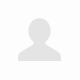
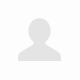

In [16]:
html_source = driver.page_source
html_source

In [17]:
from bs4 import BeautifulSoup as bs
soup = bs(html_source, 'lxml')
soup.select("div.bookListItem_title__1mWGq")

[<div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>혼자 만들면서 공부하는 파이썬</span><span> (37개 라이브러리와 API로 보고서, 차트, 게임, 맵, AI 챗봇 만들기|저자 직강 유튜브 강의, 오픈 채팅 제공)</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>혼자 공부하는 파이썬</span><span> (1:1 과외하듯 배우는 프로그래밍 자습서)</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>Do it! 점프 투 파이썬</span><span> (중학생도 첫날부터 실습하는 초고속 입문서)</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>파이썬</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>파이썬</span><span> (제2판)</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>파이썬</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>파이썬</span><span> (비전공자를위한 파이썬 기초 입문서)</span></s

# 웹페이지가 모두 로딩 될 때 까지 기다리기
* from selenium.webdrive.support.ui import WebDriverWait
* from selenium.webdrive.support import expected_conditions as EC

In [24]:
from selenium.common.exceptions import TimeoutException

try:
    button = WebDriverWait(driver, 10).until(
        EC.element_to_be_clickable((By.ID, "submit-button"))
    )
    button.click()
except TimeoutException:
    print("버튼을 찾지 못했거나 클릭할 수 없습니다.")

버튼을 찾지 못했거나 클릭할 수 없습니다.


In [23]:
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

wait = WebDriverWait(driver, 10)
button = wait.until(EC.element_to_be_clickable((By.ID, "submit-button")))
button.click()

TimeoutException: Message: 
Stacktrace:
	GetHandleVerifier [0x0107C7F3+24435]
	(No symbol) [0x01002074]
	(No symbol) [0x00ED06E3]
	(No symbol) [0x00F18B39]
	(No symbol) [0x00F18E8B]
	(No symbol) [0x00F61AC2]
	(No symbol) [0x00F3D804]
	(No symbol) [0x00F5F20A]
	(No symbol) [0x00F3D5B6]
	(No symbol) [0x00F0C54F]
	(No symbol) [0x00F0D894]
	GetHandleVerifier [0x013870A3+3213347]
	GetHandleVerifier [0x0139B0C9+3295305]
	GetHandleVerifier [0x0139558C+3271948]
	GetHandleVerifier [0x01117360+658144]
	(No symbol) [0x0100B27D]
	(No symbol) [0x01008208]
	(No symbol) [0x010083A9]
	(No symbol) [0x00FFAAC0]
	BaseThreadInitThunk [0x75B7FCC9+25]
	RtlGetAppContainerNamedObjectPath [0x771682AE+286]
	RtlGetAppContainerNamedObjectPath [0x7716827E+238]


네이버 가격비교 도서에서 파이썬 책 찾아서 5페이지 정보 데이터 프레임으로 만들기

In [25]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )
url = "https://search.shopping.naver.com/book/home"
driver.get(url)
wait = WebDriverWait(driver, 10)
search_text_box = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "._searchInput_search_text_83jy9._searchInput_placeholder_AG5yA._nlog_click")))
search_text_box.send_keys("파이썬")
search_text_box.send_keys(Keys.ENTER)


In [26]:
# 페이지 시작부터 끝까지 스크롤하기
import time
for scroll in range(0, 8001, 1000):
    driver.execute_script(f"window.scrollTo({0}, {scroll})")
    time.sleep(2)
                          
    

In [140]:
# 책 목록 전체 가져오기 find_elements
book_list = driver.find_elements(By.CSS_SELECTOR, ".bookListItem_item_book__RbpgP")

In [27]:
# 책 제목  bookListItem_title__1mWGq
title = driver.find_element(By.CSS_SELECTOR, ".bookListItem_title__1mWGq").text
#세부링크 bookListItem_item_inner__edK7P
detail_link = driver.find_element(By.CSS_SELECTOR, ".bookListItem_item_inner__edK7P > a").get_attribute("href")
# 저자 .bookListItem_define_item__jqcW8.bookListItem_define_data__fu2A5
author = driver.find_element(By.CSS_SELECTOR, ".bookListItem_define_item__jqcW8 > .bookListItem_define_data__fu2A5").text
# 출판사 .bookListItem_define_item__jqcW8 bookListItem_publish__6XykH.bookListItem_define_data__fu2A5
publisher = driver.find_element(By.CSS_SELECTOR, ".bookListItem_publish__6XykH .bookListItem_define_data__fu2A5").text
# 출간일 .bookListItem_detail_date__6_wYJ
pub_date = driver.find_element(By.CSS_SELECTOR, ".bookListItem_detail_date__6_wYJ").text
# 평점 .bookListItem_grade__e60mi
grade = float(driver.find_element(By.CSS_SELECTOR, ".bookListItem_grade__e60mi").text[2:5])
# 가격 .bookPrice_price__Nv4Ee > em
price = int(driver.find_element(By.CSS_SELECTOR, ".bookPrice_price__Nv4Ee > em").text.replace(",", ""))

print(title, detail_link, author, publisher, pub_date, grade, price)

혼자 만들면서 공부하는 파이썬 (37개 라이브러리와 API로 보고서, 차트, 게임, 맵, AI 챗봇 만들기|저자 직강 유튜브 강의, 오픈 채팅 제공) https://cr3.shopping.naver.com/book/adcr?x=O4oGsyyIzuPj1vcvFnCrlP%2F%2F%2Fw%3D%3Ds5CDt9ele2rv7%2FNy120lah%2BX0iWydDza7P5KtN0nNQ1roLdJsmLe0ih5KVXMQNR0trBU7cRem9xm5nXP36Dev8HLQfFmT02igdtXHcrQTXps9lUhgmX1cba5eb2zQ7R4z1Q3MUEsfLFYe051Nbeof0VVd6Z%2BmZ5fvTALbBBPmfKIKVnJqocqfFwLra6hFr54BChrcdh1ag7%2ByRqH4qgSPNfj6xDMeJaPTHtDIoNWns%2BM%2BoN22s6dKwm7Qn7boTIbfqCLVLVQWWN%2FLTnvTKQyWvAe%2B60h5fUDIQJz3fqbZONw%2Bd0TcbJiTH3Lys8V5OoWgcfY62%2F%2BxY4w5xbi4%2BHEPriFzevyVajC7NvPtfqyjQhzcbZ0Z%2FqemWdFziUt2qwP4tvSeAbmnTc2l2JLi8nntJqy0GxlUkP3YK7x5c6RcpMU7eVuLXKkLjcCZcHj1VgbEdjLutbeA2mDcxXgbK7%2BpO8WV5hqdhKbf%2FoSpU8YQn%2B5d1Cr06qxcu4Elc8hfnQ%2BJ4KhpNgbqqvQeo7pzFORqw%2BIQkPFlmY7lq71tmqeOJKEwKSE9XiHQj8PFMFm6RHas8fQ4rvldEGKz3BGqV5KAHmCcnlJCyRpSpVGHl2c%2Bg4rBojf87Xfr4ELDcWXztRAB6uFSzoUotvjW%2FSGxDqHVjQ%3D%3D&nvMid=52859338841&catId=50010920 문현일 한빛미디어 2025.02.14. 5.0 23400


In [28]:
# 페이지 넘김 버튼 찾기 .Paginator_list_paging__XbuO8
paginator = driver.find_element(By.CSS_SELECTOR, ".Paginator_list_paging__XbuO8")
paginator.find_element(By.LINK_TEXT, "3").click()

# 코드 합쳐서 5페이지 정보 모두 수집하기

In [29]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
import pandas as pd

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )
url = "https://search.shopping.naver.com/book/home"
driver.get(url)
wait = WebDriverWait(driver, 10)
search_text_box = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "._searchInput_search_text_83jy9._searchInput_placeholder_AG5yA._nlog_click")))
search_text_box.send_keys("파이썬")
search_text_box.send_keys(Keys.ENTER)

for num in range(1, 6):
    # 페이지 시작부터 끝까지 스크롤하기
    for scroll in range(0, 8001, 1000):
        driver.execute_script(f"window.scrollTo({0}, {scroll})")
        time.sleep(2)

    # 책 목록 전체 가져오기 find_elements
    book_list = driver.find_elements(By.CSS_SELECTOR, ".bookListItem_item_book__RbpgP")

    # 반복문을 이용해 전체 40개 책 자료 추출하기
    for book in book_list:
        # 책 제목  bookListItem_title__1mWGq
        title = book.find_element(By.CSS_SELECTOR, ".bookListItem_title__1mWGq").text
        #세부링크 bookListItem_item_inner__edK7P
        detail_link = book.find_element(By.CSS_SELECTOR, ".bookListItem_item_inner__edK7P > a").get_attribute("href")
        # 저자 .bookListItem_define_item__jqcW8.bookListItem_define_data__fu2A5
        author = book.find_element(By.CSS_SELECTOR, ".bookListItem_define_item__jqcW8 > .bookListItem_define_data__fu2A5").text
        # 출판사 .bookListItem_define_item__jqcW8 bookListItem_publish__6XykH.bookListItem_define_data__fu2A5
        publisher = book.find_element(By.CSS_SELECTOR, ".bookListItem_publish__6XykH .bookListItem_define_data__fu2A5").text
        # 출간일 .bookListItem_detail_date__6_wYJ
        pub_date = book.find_element(By.CSS_SELECTOR, ".bookListItem_detail_date__6_wYJ").text
        try:
            # 평점 .bookListItem_grade__e60mi
            grade = float(book.find_element(By.CSS_SELECTOR, ".bookListItem_grade__e60mi").text[2:5])
        except Exception:
            grade = 0.0
        try:    
            # 가격 .bookPrice_price__Nv4Ee > em
            price = int(book.find_element(By.CSS_SELECTOR, ".bookPrice_price__Nv4Ee > em").text.replace(",", ""))
        except Exception:
            price = 0

        temp = (title, detail_link, author, publisher, pub_date, grade, price)
        columns = ("title", "detail_link", "author", "publisher", "pub_date", "grade", "price")
        result = pd.DataFrame([temp], columns=columns)
        # 데이터프레임을 CSV로 저장하되 내용 추가하면서 저장하기
        result.to_csv("./scraping_results/네이버책_selenium.csv", mode="a", header=False, index=False, encoding="utf-8-sig")
        
    # 페이지 넘김 버튼 찾기 .Paginator_list_paging__XbuO8
    paginator = driver.find_element(By.CSS_SELECTOR, ".Paginator_list_paging__XbuO8")
    paginator.find_element(By.LINK_TEXT, f"{num+1}").click()

# 검색어를 입력받아 Naver 도서에서 검색하고 검색결과를 DB 모듈을 이용해 DB에 저장하기

In [32]:
pip install book_dbio

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement book_dbio (from versions: none)
ERROR: No matching distribution found for book_dbio


In [34]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
import pandas as pd
from book_dbio import to_book_db


keyword = input("검색할 책을 입력해 주세요. ")

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")
# options.add_argument("--headless")  
# options.add_argument("--no-sandbox")
# options.add_argument("--disable-dev-shm-usage")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )


url = "https://search.shopping.naver.com/book/home"
driver.get(url)
wait = WebDriverWait(driver, 10)
search_text_box = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "._searchInput_search_text_83jy9._searchInput_placeholder_AG5yA._nlog_click")))
search_text_box.send_keys(keyword)
search_text_box.send_keys(Keys.ENTER)

for num in range(1, 6):
    print(f"{num} / {len(range(1,6))} 페이지 작업중", end="\n")
    # 페이지 시작부터 끝까지 스크롤하기
    for scroll in range(0, 8001, 1000):
        driver.execute_script(f"window.scrollTo({0}, {scroll})")
        time.sleep(0.5)

    # 책 목록 전체 가져오기 find_elements
    book_list = driver.find_elements(By.CSS_SELECTOR, ".bookListItem_item_book__RbpgP")

    # 반복문을 이용해 전체 40개 책 자료 추출하기
    for idx, book in enumerate(book_list):
        # 책 제목  bookListItem_title__1mWGq
        title = book.find_element(By.CSS_SELECTOR, ".bookListItem_title__1mWGq").text
        #세부링크 bookListItem_item_inner__edK7P
        detail_link = book.find_element(By.CSS_SELECTOR, ".bookListItem_item_inner__edK7P > a").get_attribute("href")
        # 저자 .bookListItem_define_item__jqcW8.bookListItem_define_data__fu2A5
        author = book.find_element(By.CSS_SELECTOR, ".bookListItem_define_item__jqcW8 > .bookListItem_define_data__fu2A5").text
        # 출판사 .bookListItem_define_item__jqcW8 bookListItem_publish__6XykH.bookListItem_define_data__fu2A5
        publisher = book.find_element(By.CSS_SELECTOR, ".bookListItem_publish__6XykH .bookListItem_define_data__fu2A5").text
        try:
            # 출간일 .bookListItem_detail_date__6_wYJ
            pub_date = book.find_element(By.CSS_SELECTOR, ".bookListItem_detail_date__6_wYJ").text
        except Exception:
            pub_date = "Unknown"
        try:
            # 평점 .bookListItem_grade__e60mi
            grade = float(book.find_element(By.CSS_SELECTOR, ".bookListItem_grade__e60mi").text[2:5])
        except Exception:
            grade = 0.0
        try:    
            # 가격 .bookPrice_price__Nv4Ee > em
            price = int(book.find_element(By.CSS_SELECTOR, ".bookPrice_price__Nv4Ee > em").text.replace(",", ""))
        except Exception:
            price = 0

        temp = (title, detail_link, author, publisher, pub_date, grade, price)
        columns = ("title", "detail_link", "author", "publisher", "pub_date", "grade", "price")
        result = pd.DataFrame([temp], columns=columns)
        # 데이터프레임을 CSV로 저장하되 내용 추가하면서 저장하기
        to_book_db(keyword, result)
#         result.to_csv("./scraping_results/네이버책_selenium.csv", mode="a", header=False, index=False, encoding="utf-8-sig")
        print(f"                                                       {idx+1}/{len(book_list)} DB 저장완료", end="\r")
    # 페이지 넘김 버튼 찾기 .Paginator_list_paging__XbuO8
    paginator = driver.find_element(By.CSS_SELECTOR, ".Paginator_list_paging__XbuO8")
    paginator.find_element(By.LINK_TEXT, f"{num+1}").click()

검색할 책을 입력해 주세요. 파이썬
1 / 5 페이지 작업중
2 / 5 페이지 작업중                                          40/40 DB 저장완료
3 / 5 페이지 작업중                                          40/40 DB 저장완료
4 / 5 페이지 작업중                                          40/40 DB 저장완료
5 / 5 페이지 작업중                                          40/40 DB 저장완료
